In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset
# Load the official Ames Housing dataset via OpenML/URL
# https://www.sciencedirect.com/science/article/pii/S2352340925008765
url = "https://raw.githubusercontent.com/wblakecannon/ames/refs/heads/master/data/housing.csv"
df = pd.read_csv(url)

In [2]:
# Clean column names (remove spaces)
df.columns = df.columns.str.replace(' ', '_')


# Select Features (Numeric + Categorical)
num_features = ['Overall_Qual', 'Gr_Liv_Area', 'Garage_Area', 'Total_Bsmt_SF', 'Year_Built']
cat_feature = ['Mas_Vnr_Type']
target = 'SalePrice'

# Clean dataset: handle missing values in target and numerical features
housing = df[num_features + cat_feature + [target]].copy()

# Fill missing values in Mas_Vnr_Type with 'None' (meaning no masonry veneer)
housing['Mas_Vnr_Type'] = housing['Mas_Vnr_Type'].fillna('None')
housing = housing.dropna()
housing.head(10)

,Overall_Qual,Gr_Liv_Area,Garage_Area,Total_Bsmt_SF,Year_Built,Mas_Vnr_Type,SalePrice
0,6,1656,528.0,1080.0,1960,Stone,215000
1,5,896,730.0,882.0,1961,None,105000
2,6,1329,312.0,1329.0,1958,BrkFace,172000
3,7,2110,522.0,2110.0,1968,None,244000
4,5,1629,482.0,928.0,1997,None,189900
5,6,1604,470.0,926.0,1998,BrkFace,195500
6,8,1338,582.0,1338.0,2001,None,213500
7,8,1280,506.0,1280.0,1992,None,191500
8,8,1616,608.0,1595.0,1995,None,236500
9,7,1804,442.0,994.0,1999,None,189000


In [3]:
freq_table = df['Mas_Vnr_Type'].value_counts(dropna=False).reset_index()
freq_table.columns = ['Mas_Vnr_Type', 'Frequency']
print(freq_table)

# Create Dummy Variables (One-Hot Encoding)
# dropping first may not be necessary/beneficial
housing_encoded = pd.get_dummies(housing, columns=cat_feature, drop_first=True)

# Separate features (X) and target (y)
X = housing_encoded.drop(columns=[target])
y = housing_encoded[target]

X.head()

  Mas_Vnr_Type  Frequency
0          NaN       1775
1      BrkFace        880
2        Stone        249
3       BrkCmn         25
4       CBlock          1


,Overall_Qual,Gr_Liv_Area,Garage_Area,Total_Bsmt_SF,Year_Built,Mas_Vnr_Type_BrkFace,Mas_Vnr_Type_CBlock,Mas_Vnr_Type_None,Mas_Vnr_Type_Stone
0,6,1656,528.0,1080.0,1960,False,False,False,True
1,5,896,730.0,882.0,1961,False,False,True,False
2,6,1329,312.0,1329.0,1958,True,False,False,False
3,7,2110,522.0,2110.0,1968,False,False,True,False
4,5,1629,482.0,928.0,1997,False,False,True,False


In [4]:
# Split Train/Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
# Standardize Features
#  numerical metrics AND 0/1 dummy indicators must be scaled
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


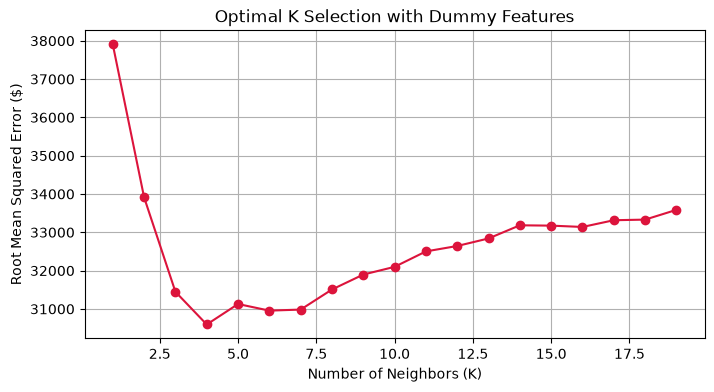

In [6]:
# Find Optimal K via Hyperparameter Tuning
rmse_list = []
k_range = range(1, 20)

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_list.append(rmse)

# Plotting Tuning Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, rmse_list, marker='o', color='crimson')
plt.title('Optimal K Selection with Dummy Features')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Root Mean Squared Error ($)')
plt.grid(True)
plt.show()

In [7]:
# Evaluate Final Model
best_k = k_range[np.argmin(rmse_list)]
final_knn = KNeighborsRegressor(n_neighbors=best_k, weights='distance')
final_knn.fit(X_train_scaled, y_train)
final_preds = final_knn.predict(X_test_scaled)

print(f"Optimal K: {best_k}")
print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test, final_preds):,.2f}")
print(f"Model R^2 Score: {r2_score(y_test, final_preds):.3f}")

Optimal K: 4
Mean Absolute Error (MAE): $20,250.52
Model R^2 Score: 0.886


In [8]:
# Helper function to format and predict new properties
def predict_house_price(overall_qual, gr_liv_area, garage_area, total_bsmt_sf, year_built, mas_vnr_type):
    # 1. Create single-row DataFrame
    new_house = pd.DataFrame([{
        'Overall_Qual': overall_qual,
        'Gr_Liv_Area': gr_liv_area,
        'Garage_Area': garage_area,
        'Total_Bsmt_SF': total_bsmt_sf,
        'Year_Built': year_built,
        'Mas_Vnr_Type': mas_vnr_type
    }])
    
    # 2. Get dummies and reindex to match training columns
    new_house_encoded = pd.get_dummies(new_house, columns=['Mas_Vnr_Type'])
    new_house_encoded = new_house_encoded.reindex(columns=X.columns, fill_value=0)
    
    # 3. Scale and Predict
    new_house_scaled = scaler.transform(new_house_encoded)
    predicted_val = final_knn.predict(new_house_scaled)[0]
    
    return predicted_val

# Example: Predict price for a home with Stone veneer vs. No veneer
price_stone = predict_house_price(7, 1800, 500, 900, 2005, 'BrkFace')
price_none = predict_house_price(7, 1800, 500, 900, 2005, 'None')

print(f"Estimated Price (Brick Face): ${price_stone:,.2f}")
print(f"Estimated Price (No Veneer):    ${price_none:,.2f}")

Estimated Price (Brick Face): $209,021.94
Estimated Price (No Veneer):    $198,534.91


In [9]:
# https://www.sciencedirect.com/science/article/pii/S2352340925008765
# save augmented file from the Zenodo data
df_geo = pd.read_csv("ames_spatialized_indexed.csv")

# merge the two dataframes using the "Order", called "X" in the spatialized version
# manually inspect to make sure the actual houses match


df_merged = pd.merge(
      df,
      df_geo[["X", "geometry...99"]],
      left_on="Order",
      right_on="X",
      how="left",
  )

# break R notation vector into separate fields
coords = df_merged['geometry...99'].str.extract(r'c\(([-0-9\.]+),\s*([-0-9\.]+)\)')

# Convert to float and assign to separate columns
df_merged['Longitude'] = coords[0].astype(float)
df_merged['Latitude'] = coords[1].astype(float)

df_merged.head()

,Unnamed:_0,Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,...,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice,X,geometry...99,Longitude,Latitude
0,0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,...,0,5,2010,WD,Normal,215000,1,"c(-93.619754, 42.054035)",-93.619754,42.054035
1,1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,...,0,6,2010,WD,Normal,105000,2,"c(-93.619756, 42.053014)",-93.619756,42.053014
2,2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,...,12500,6,2010,WD,Normal,172000,3,"c(-93.6193873, 42.052659)",-93.619387,42.052659
3,3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,...,0,4,2010,WD,Normal,244000,4,"c(-93.61732, 42.051245)",-93.617320,42.051245
4,4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,...,0,3,2010,WD,Normal,189900,5,"c(-93.638933, 42.060899)",-93.638933,42.060899


 - KNN's sensitivity to irrelevant attributes.
 - predict binary/categorical variable (e.g. Garage_Type?)
 - measure accuracy
 - re-do KNN with lat/lng

In [10]:
freq_table = df['Garage_Type'].value_counts(dropna=False).reset_index()
freq_table.columns = ['Garage_Type', 'Frequency']
print(freq_table)

  Garage_Type  Frequency
0      Attchd       1731
1      Detchd        782
2     BuiltIn        186
3         NaN        157
4     Basment         36
5      2Types         23
6     CarPort         15
